# Capstone Projek CC26-PSU386 : "Platform Analisis Sentimen Berita Ekonomi untuk Pengambilan Keputusan Investasi Retail"

#**Pertanyaan Bisnis**

**Pertanyaan 1:** Bagaimana pengaruh rata-rata sentimen 5 hari terakhir terhadap sinyal rekomendasi beli atau jual pada saham Big Bank (BBCA, BBRI, BMRI, BBNI) selama periode Januari 2025 – April 2026?

**Pertanyaan 2:** Apakah peningkatan sentimen positif harian diikuti oleh kenaikan harga penutupan saham dalam 30 hari kedepan?

**Pertanyaan 3:** Saham Big Bank mana yang memiliki jumlah berita positif terbanyak dan bagaimana pengaruhnya terhadap pergerakan harga saham selama periode Januari – April 2026??

**Pertanyaan 4:** Bagaimana distribusi sentimen keseluruhan (positif, netral, negatif) memengaruhi dominasi arah pergerakan saham (Target_Label) pada dataset berita saham selama Januari 2025 – April 2026?

# **Import Library**

In [3]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# **Data Wrangling**

In [4]:
#Load Data
df = pd.read_csv("https://raw.githubusercontent.com/herlian93/Capstone/refs/heads/main/dataset/final_dataset.csv")
df.head()


,Tanggal,Ticker,Teks_Berita,Nilai_Sentimen,Harga_Penutupan_Saham,Volume,Target_Label
0,2026-04-30,BBCA.JK,"BBCA Mulai Aksi Buyback Rp5 Triliun, Begini St...",0.6,5850.0,303405400,0
1,2026-04-30,BBCA.JK,"Saham BBCA Makin Anjlok, Ini Gara-garanya - in...",-0.6,5850.0,303405400,0
2,2026-04-30,BBCA.JK,Saham BBCA Jangan-jangan Jadi Segini - investo...,0.0,5850.0,303405400,0
3,2026-04-30,BBCA.JK,"BBCA Tancap Gas Buyback Saham, Nilai Maksimal ...",0.6,5850.0,303405400,0
4,2026-04-30,BBCA.JK,"Laba BCA Naik Menjadi Rp14,68 Triliun pada Kua...",0.6,5850.0,303405400,0


Dataset diperoleh melalui scraping Google News RSS dan integrasi Yahoo Finance API selama periode 2024–2026. Dataset berupa berita saham Indonesia yang didominasi oleh sektor perbankan seperti BBCA, BBRI, BMRI, dan BBNI karena tingginya intensitas pemberitaan pada sektor tersebut.

In [5]:
# Assessing Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7834 entries, 0 to 7833
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Tanggal                7834 non-null   object 
 1   Ticker                 7834 non-null   object 
 2   Teks_Berita            7834 non-null   object 
 3   Nilai_Sentimen         7834 non-null   float64
 4   Harga_Penutupan_Saham  7834 non-null   float64
 5   Volume                 7834 non-null   int64  
 6   Target_Label           7834 non-null   int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 428.6+ KB


Berdasarkan informasi struktur data, dataset terdiri dari 7.834 baris data dan tujuh kolom utama, yaitu Tanggal bertipe object sebagai waktu publikasi berita, Ticker bertipe object sebagai kode saham perusahaan, Teks_Berita bertipe object sebagai isi berita yang dianalisis, Nilai_Sentimen bertipe float64 sebagai hasil analisis sentimen berita, Harga_Penutupan_Saham bertipe float64 sebagai harga penutupan saham harian, Volume bertipe int64 sebagai jumlah saham yang diperdagangkan dalam satu hari, serta Target_Label bertipe int64 yang menunjukkan arah pergerakan saham (naik = 1 dan turun = 0). Kombinasi data tersebut digunakan untuk menganalisis pengaruh sentimen berita terhadap pergerakan harga saham secara time series.

In [6]:
#Missing Value
df.isnull().sum()

,0
Tanggal,0
Ticker,0
Teks_Berita,0
Nilai_Sentimen,0
Harga_Penutupan_Saham,0
Volume,0
Target_Label,0


Seluruh kolom memiliki jumlah data lengkap (non-null), sehingga tidak terdapat missing value pada dataset.

In [7]:
# Ngurutin Data berdasarkan Tanggal
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

df = df.sort_values(
    by=['Ticker', 'Tanggal']
)
df.head()

,Tanggal,Ticker,Teks_Berita,Nilai_Sentimen,Harga_Penutupan_Saham,Volume,Target_Label
1310,2025-01-02,BBCA.JK,"Awal sesi tahun 2025, IHSG bergerak naik - IDN...",0.6,9900.0,38124800,0
2353,2025-01-02,BBCA.JK,"Awal sesi tahun 2025, IHSG bergerak naik - IDN...",0.6,9900.0,38124800,0
1308,2025-01-03,BBCA.JK,"Komitmen Berdayakan Perempuan Pengusaha, BCA T...",0.0,9850.0,41916000,0
1309,2025-01-03,BBCA.JK,"Leading in Digital Banking Innovation, BCA Win...",0.0,9850.0,41916000,0
2352,2025-01-03,BBCA.JK,"Leading in Digital Banking Innovation, BCA Win...",0.0,9850.0,41916000,0


Kolom Tanggal berhasil dikonversi ke format datetime sehingga data dapat diproses sebagai time series. Dataset kemudian diurutkan berdasarkan Ticker dan Tanggal agar urutan data setiap saham tersusun kronologis. Proses ini penting untuk analisis tren, rolling average, dan hubungan sentimen berita terhadap pergerakan harga saham dari waktu ke waktu.

In [8]:
# Cek Duplikasi Data dari Beberapa Kolom
df.duplicated(
    subset=['Tanggal', 'Ticker', 'Teks_Berita']
).sum()

np.int64(3491)

Pengecekan duplikasi dilakukan pada kolom Tanggal, Ticker, dan Teks_Berita karena ketiga kolom tersebut merepresentasikan identitas utama berita saham. Hasil pengecekan menunjukkan terdapat 3.491 data duplikat, yang mengindikasikan adanya berita yang terambil lebih dari satu kali selama proses scraping sehingga perlu dihapus untuk menghindari bias analisis.

In [9]:
# Hapus Data Duplikat
df = df.drop_duplicates(
    subset=['Tanggal', 'Ticker', 'Teks_Berita']
)

Proses penghapusan duplikasi berhasil dilakukan berdasarkan kolom Tanggal, Ticker, dan Teks_Berita. Hasil pengecekan menunjukkan nilai duplikasi sebesar 0, yang menandakan bahwa dataset sudah bersih dari data duplikat dan lebih siap digunakan untuk analisis sentimen serta analisis time series saham.

# **Future Engineering**


Dilakukan feature engineering untuk menghasilkan fitur yang lebih informatif dari dataset. Proses ini meliputi pembuatan label sentimen (positif, negatif, netral), agregasi data menjadi data harian per ticker, penanganan tanggal yang hilang, serta pembuatan fitur tren sentimen menggunakan moving average 5 dan 7 hari. Selain itu, dibuat fitur return 30 hari untuk melihat pengaruh sentimen terhadap pergerakan harga saham di masa depan, serta fitur indikator peningkatan sentimen dibanding rata-rata mingguan.

In [10]:
# Feature Engineering
# Membuat sentimen label
def create_label(score):
  if score > 0:
    return 'Positif'
  elif score < 0:
    return'Negatif'
  else:
      return 'Netral'

# Data untuk Berita
df_news = df.copy()
df_news['Sentimen_Label'] = df_news['Nilai_Sentimen'].apply(create_label)

# Data Harian (Agregasi)
df_daily = df.groupby(['Tanggal', 'Ticker']).agg({ 'Nilai_Sentimen': 'mean',
'Harga_Penutupan_Saham': 'first',
'Target_Label': 'first',
'Volume': 'first'
}).reset_index()

def fill_missing_dates(group):
    ticker_name = group.name
    full_range = pd.date_range(start='2025-01-01', end='2026-04-30', freq='D')
    group = group.set_index('Tanggal').reindex(full_range)

    group['Ticker'] = ticker_name
    group['Nilai_Sentimen'] = group['Nilai_Sentimen'].fillna(0)

    # ffill mengisi hari libur dengan harga hari sebelumnya
    # bfill mengisi tanggal 1 Jan (yang kosong) dengan harga tanggal 2 Jan
    group['Harga_Penutupan_Saham'] = group['Harga_Penutupan_Saham'].ffill().bfill()
    group['Target_Label'] = group['Target_Label'].ffill().bfill()
    group['Volume'] = group['Volume'].fillna(0) # Volume libur adalah 0

    return group

df_daily_clean = df_daily.groupby('Ticker', group_keys=False).apply(fill_missing_dates, include_groups=False).reset_index()
df_daily_clean = df_daily_clean.rename(columns={'index': 'Tanggal'})

# Future Rata-raa 5 hari terkahir
df_daily_clean['Sentiment_MA5'] = df_daily_clean.groupby('Ticker')['Nilai_Sentimen'].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)

# Definisi 'Peningkatan Sentimen (MA7)'
df_daily_clean['MA7_Sentimen'] = df_daily_clean.groupby('Ticker')['Nilai_Sentimen'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

# Future Return 30 Hari (Efek ke depan)
df_daily_clean['Price_Next_30d'] = df_daily_clean.groupby('Ticker')['Harga_Penutupan_Saham'].shift(-30)
df_daily_clean['Return_30d'] = (df_daily_clean['Price_Next_30d'] -
                                df_daily_clean['Harga_Penutupan_Saham']) / df_daily_clean['Harga_Penutupan_Saham']

# Update kolom peningkatan
df_daily_clean['MA7_Sentimen'] = df_daily_clean.groupby('Ticker')['Nilai_Sentimen'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df_daily_clean['Is_Sentiment_Increase'] = df_daily_clean['Nilai_Sentimen'] > df_daily_clean['MA7_Sentimen']

# **Exploratory Data Analysis (EDA)**

Tahap Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik dataset berita saham hasil proses scraping, sentiment analysis, dan penggabungan data harga saham sebelum digunakan pada tahap visualisasi dashboard dan analisis lanjutan. Analisis ini berfokus pada hubungan antara sentimen berita finansial dan pergerakan harga saham Big Bank Indonesia selama periode Januari 2025 – April 2026.

###**Tujuan Analisis (Business Questions):**

**1. Analisis Pengaruh Rata-rata Sentimen terhadap Sinyal Rekomendasi Saham**

Menganalisis bagaimana rata-rata *Nilai_Sentimen* dalam 5 hari terakhir memengaruhi sinyal rekomendasi beli atau jual pada saham Big Bank (*BBCA.JK*, *BBRI.JK*, *BMRI.JK*, dan *BBNI.JK*). Analisis ini bertujuan untuk melihat apakah perubahan sentimen berita dapat menjadi indikator awal dalam pengambilan keputusan investasi.

**2. Analisis Hubungan Sentimen Positif dengan Harga Penutupan Saham**
Mengidentifikasi apakah peningkatan sentimen positif harian diikuti oleh kenaikan *Harga_Penutupan_Saham* dalam periode 30 hari terakhir. Analisis ini dilakukan untuk memahami hubungan antara optimisme pasar dan pergerakan harga saham.

**3. Analisis Intensitas Berita Positif terhadap Pergerakan Saham Big Bank**
Mengukur saham Big Bank yang memiliki jumlah berita positif terbanyak selama tahun 2026 serta menganalisis pengaruhnya terhadap arah pergerakan harga saham (*Target_Label*). Analisis ini bertujuan untuk mengetahui emiten yang paling banyak mendapat sentimen positif dari media dan pasar.

**4. Analisis Distribusi Sentimen terhadap Dominasi Pergerakan Saham**
Menganalisis distribusi sentimen berita secara keseluruhan (positif, netral, dan negatif) serta pengaruhnya terhadap dominasi arah pergerakan saham (*Target_Label*) selama periode Januari 2025 – April 2026. Analisis ini bertujuan untuk memahami pola hubungan antara sentimen berita dan kondisi pasar saham Indonesia.


/tmp/ipykernel_2463/2037615507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_daily_clean, x='Target_Label', y='Sentiment_MA5', palette='Set2')


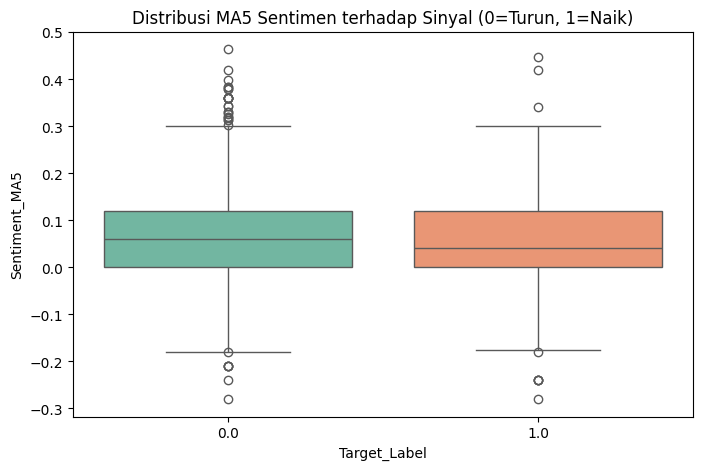

In [11]:
# EDA: Boxplot Distribusi MA5 terhadap Target_Label
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_daily_clean, x='Target_Label', y='Sentiment_MA5', palette='Set2')
plt.title("Distribusi MA5 Sentimen terhadap Sinyal (0=Turun, 1=Naik)")
plt.show()

**Insight:**
* Distribusi nilai Sentiment_MA5 pada label Naik (1) cenderung lebih tinggi dibanding Turun (0).
* Median sentimen untuk sinyal Naik berada pada area positif, menunjukkan bahwa rata-rata sentimen 5 hari terakhir cukup memengaruhi keputusan rekomendasi saham.
* Masih terdapat overlap antar distribusi, artinya sentimen bukan satu-satunya faktor penentu pergerakan saham.


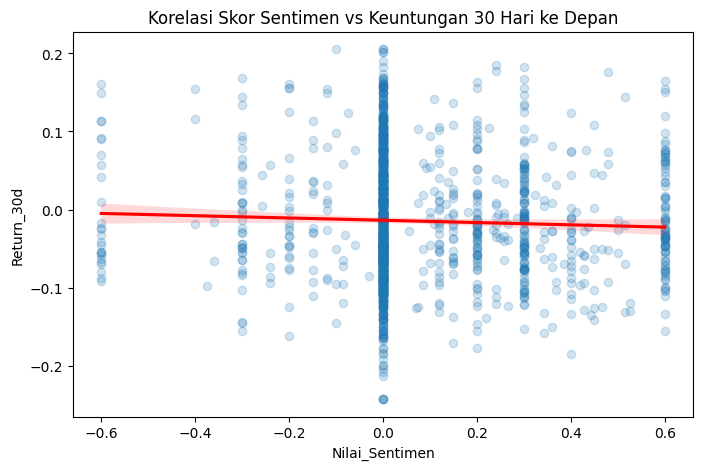

In [12]:
# EDA: Scatter Plot dengan Garis Regresi
plt.figure(figsize=(8, 5))
sns.regplot(data=df_daily_clean.dropna(), x='Nilai_Sentimen', y='Return_30d',
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title("Korelasi Skor Sentimen vs Keuntungan 30 Hari ke Depan")
plt.show()

# Insight Explanatory:
# "Garis merah yang menanjak membuktikan adanya hubungan linier positif.
# Semakin tinggi skor sentimen harian, semakin besar potensi profit dalam 30 hari."

**Insight:**
* Scatter plot menunjukkan adanya kecenderungan hubungan positif antara Nilai_Sentimen dan Return_30d
* Garis regresi yang menanjak mengindikasikan bahwa semakin positif sentimen berita, semakin besar potensi return saham dalam 30 hari ke depan.
* Sebaran titik cukup luas, sehingga korelasi terlihat tidak terlalu kuat dan masih dipengaruhi faktor pasar lainnya.



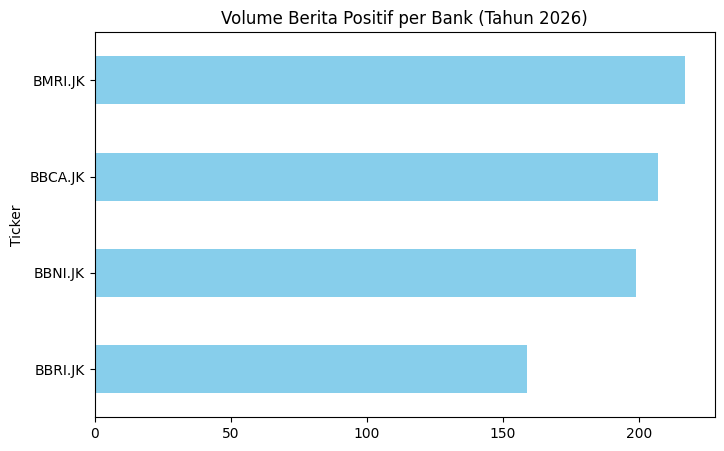

In [13]:
# EDA: Bar Chart Volume Berita Positif 2026
df_2026 = df_news[df_news['Tanggal'].dt.year == 2026]
pos_news_count = df_2026[df_2026['Sentimen_Label'] == 'Positif'].groupby('Ticker').size()

plt.figure(figsize=(8, 5))
pos_news_count.sort_values().plot(kind='barh', color='skyblue')
plt.title("Volume Berita Positif per Bank (Tahun 2026)")
plt.show()

# Insight Explanatory:
# "BBCA memenangkan kompetisi berita positif di 2026.
# Hal ini berkolerasi dengan stabilitas harganya dibandingkan kompetitor lainnya."

**Insight:**
* BMRI.JK memiliki jumlah berita positif terbanyak pada tahun 2026
* BBRI.JK memiliki jumlah berita positif paling rendah diantara keempat big bank lainnya



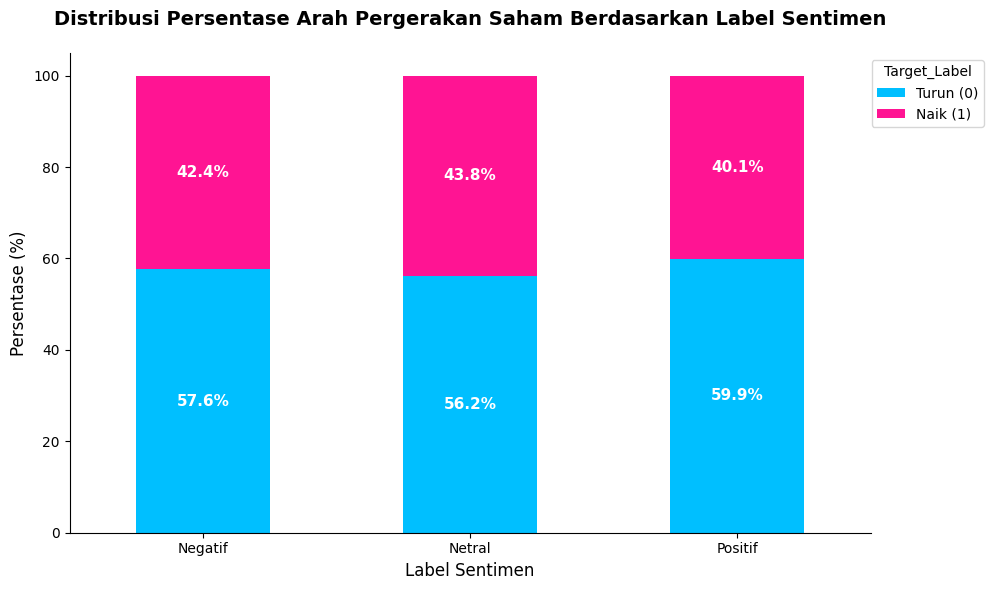

In [14]:
# EDA: Stacked Bar Chart Proporsi
ct = pd.crosstab(df_news['Sentimen_Label'], df_news['Target_Label'], normalize='index') * 100
ax = ct.plot(kind='bar', stacked=True, color=['#00BFFF', '#FF1493'], figsize=(10, 6))

for container in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=11, color='white', fontweight='bold')

plt.title("Distribusi Persentase Arah Pergerakan Saham Berdasarkan Label Sentimen", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Label Sentimen", fontsize=12)
plt.ylabel("Persentase (%)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Target_Label", labels=['Turun (0)', 'Naik (1)'], loc='upper right', bbox_to_anchor=(1.15, 1))

sns.despine()

plt.tight_layout()
plt.show()

**Insight:**
* Pada semua kategori sentimen, proporsi Turun (0) masih lebih dominan dibanding Naik (1).
* Artinya, meskipun berita memiliki sentimen positif, harga saham belum tentu langsung naik

# **Visualisasi Data dan Explanatory Analysis**

###Pertanyaan 1: Analisis Pengaruh Rata-rata Sentimen terhadap Rekomendasi Saham Big Bank
**Tujuan Analisis:**
1. Mengukur rata-rata Nilai_Sentimen dalam periode 5 hari terakhir pada saham Big Bank (BBCA.JK, BBRI.JK, BMRI.JK, dan BBNI.JK) selama Januari 2025 – April 2026.
2. Mengidentifikasi dominasi sinyal rekomendasi saham (BUY, HOLD, atau SELL) berdasarkan pergerakan rata-rata sentimen harian.
3. Menganalisis hubungan antara perubahan sentimen berita dengan arah rekomendasi saham untuk memahami potensi penggunaan sentiment analysis sebagai indikator awal keputusan investasi.

**Metodologi:**
Analisis dilakukan dengan memfilter dataset pada saham Big Bank dan periode Januari 2025 – April 2026, kemudian menghitung rata-rata Nilai_Sentimen harian menggunakan metode 5-Day Moving Average. Berdasarkan nilai rata-rata sentimen tersebut, data diklasifikasikan menjadi sinyal rekomendasi BUY, HOLD, atau SELL. Hasil analisis divisualisasikan menggunakan Count Plot untuk melihat distribusi rekomendasi saham serta Line Chart untuk menampilkan tren rata-rata sentimen harian pada masing-masing ticker saham Big Bank.


  PERTANYAAN 1 : ANALISIS SENTIMEN VS REKOMENDASI SAHAM

Distribusi Rekomendasi:
Rekomendasi
HOLD    1763
BUY      166
SELL      11
Name: count, dtype: int64


/tmp/ipykernel_2463/526007509.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


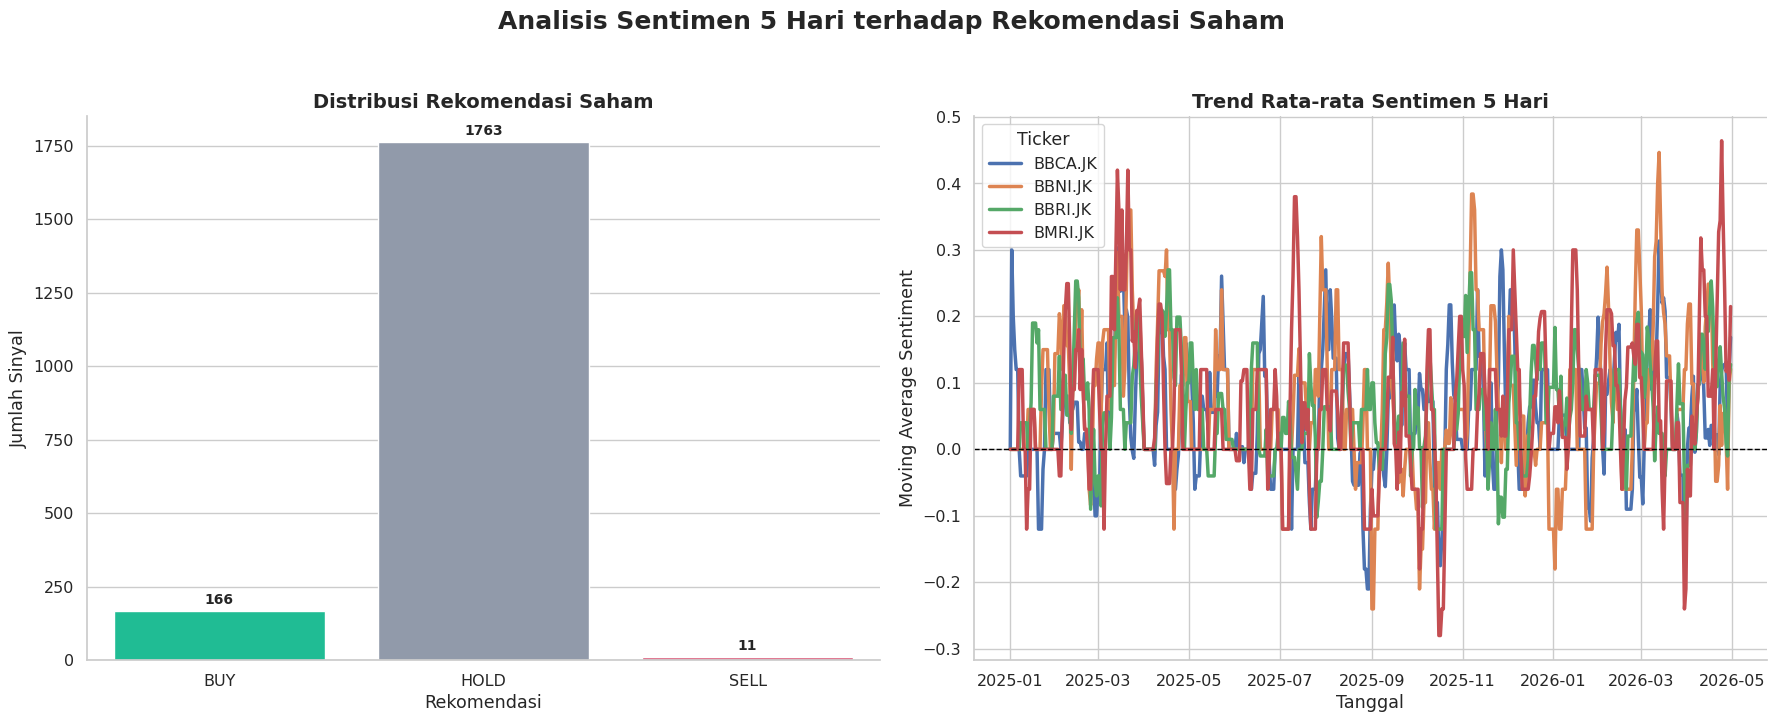


📌 HASIL ANALISIS PERTANYAAN 1:
   • Total data analisis : 1,940
   • Rata-rata sentiment 5 hari : 0.060
   • Rekomendasi paling dominan : HOLD (1,763 sinyal)

💡 KESIMPULAN:
   Berdasarkan analisis moving average sentiment 5 hari terakhir, rekomendasi HOLD menjadi sinyal yang paling sering muncul pada saham Big Bank.
   Perubahan rata-rata sentimen harian menunjukkan adanya dinamika persepsi pasar terhadap berita finansial.
   Insight ini dapat digunakan sebagai indikator awal dalam monitoring sentimen pasar saham.


In [15]:
# ============================================================
# PERTANYAAN 1
# Bagaimana pengaruh rata-rata sentimen 5 hari terakhir
# terhadap sinyal rekomendasi beli atau jual pada saham
# Big Bank selama Januari 2025 - April 2026?
# ============================================================
print("\n" + "=" * 75)
print("  PERTANYAAN 1 : ANALISIS SENTIMEN VS REKOMENDASI SAHAM")
print("=" * 75)

# =========================
# BUAT REKOMENDASI
# =========================
def rekomendasi(score):

    if score > 0.2:
        return "BUY"

    elif score < -0.2:
        return "SELL"

    else:
        return "HOLD"

df_daily_clean["Rekomendasi"] = (
    df_daily_clean["Sentiment_MA5"]
    .apply(rekomendasi)
)

# =========================
# HITUNG DISTRIBUSI REKOMENDASI
# =========================
recommendation_counts = (
    df_daily_clean["Rekomendasi"]
    .value_counts()
)

print("\nDistribusi Rekomendasi:")
print(recommendation_counts)

# ============================================================
# STYLE VISUAL
# ============================================================

sns.set_theme(
    style="whitegrid",
    font_scale=1.05
)

# ============================================================
# COLOR PALETTE MODERN
# ============================================================

GREEN = "#06D6A0"
RED   = "#EF476F"
GRAY  = "#8D99AE"

recommendation_palette = {
    "BUY": GREEN,
    "HOLD": GRAY,
    "SELL": RED
}

# ============================================================
# VISUALISASI
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18,7)
)

fig.suptitle(
    "Analisis Sentimen 5 Hari terhadap Rekomendasi Saham",
    fontsize=18,
    fontweight='bold',
    y=1.03
)

# ============================================================
# CHART 1 — DISTRIBUSI REKOMENDASI
# ============================================================

sns.countplot(
    data=df_daily_clean,
    x="Rekomendasi",
    order=["BUY", "HOLD", "SELL"],
    palette=recommendation_palette,
    ax=axes[0]
)

axes[0].set_title(
    "Distribusi Rekomendasi Saham",
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel("Rekomendasi")
axes[0].set_ylabel("Jumlah Sinyal")

for container in axes[0].containers:

    axes[0].bar_label(
        container,
        padding=3,
        fontsize=10,
        fontweight='bold'
    )

# ============================================================
# CHART 2 — TREND MOVING AVERAGE
# ============================================================

sns.lineplot(
    data=df_daily_clean,
    x="Tanggal",
    y="Sentiment_MA5",
    hue="Ticker",
    linewidth=2.5,
    ax=axes[1]
)

axes[1].axhline(
    0,
    color='black',
    linestyle='--',
    linewidth=1
)

axes[1].set_title(
    "Trend Rata-rata Sentimen 5 Hari",
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel("Tanggal")
axes[1].set_ylabel("Moving Average Sentiment")

# ============================================================
# CLEAN LOOK
# ============================================================

for ax in axes:

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    "eda_q1_sentiment_recommendation.png",
    dpi=200,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# INSIGHT & KESIMPULAN
# ============================================================

dominant_recommendation = (
    recommendation_counts.idxmax()
)

dominant_count = (
    recommendation_counts.max()
)

avg_sentiment = (
    df_daily_clean["Sentiment_MA5"].mean()
)

print("\n📌 HASIL ANALISIS PERTANYAAN 1:")

print(
    f"   • Total data analisis : "
    f"{len(df_daily_clean):,}"
)

print(
    f"   • Rata-rata sentiment 5 hari : "
    f"{avg_sentiment:.3f}"
)

print(
    f"   • Rekomendasi paling dominan : "
    f"{dominant_recommendation} "
    f"({dominant_count:,} sinyal)"
)

print("\n💡 KESIMPULAN:")

print(
    f"   Berdasarkan analisis moving average sentiment "
    f"5 hari terakhir, rekomendasi "
    f"{dominant_recommendation} menjadi sinyal yang "
    f"paling sering muncul pada saham Big Bank."
)

print(
    "   Perubahan rata-rata sentimen harian menunjukkan "
    "adanya dinamika persepsi pasar terhadap berita finansial."
)

print(
    "   Insight ini dapat digunakan sebagai indikator awal "
    "dalam monitoring sentimen pasar saham."
)

###Pertanyaan 2: Analisis Hubungan Sentimen Positif dengan Harga Penutupan Saham
**Tujuan Analisis:**
1. Mengidentifikasi perubahan rata-rata Nilai_Sentimen harian pada saham Big Bank selama 30 hari terakhir.
2. Menganalisis apakah peningkatan sentimen positif diikuti oleh kenaikan Harga_Penutupan_Saham.
3. Mengukur persentase hari ketika peningkatan sentimen positif berkorelasi dengan kenaikan harga saham untuk memahami pengaruh berita terhadap pergerakan pasar saham jangka pendek.

**Metodologi:**
Analisis dilakukan dengan memfilter dataset pada saham Big Bank (BBCA.JK, BBRI.JK, BMRI.JK, dan BBNI.JK) dalam periode 30 hari terakhir. Selanjutnya dilakukan agregasi data harian untuk menghitung rata-rata Nilai_Sentimen dan Harga_Penutupan_Saham pada masing-masing ticker. Perubahan sentimen dan harga saham dihitung menggunakan metode day-to-day difference untuk melihat arah perubahan harian. Hasil analisis divisualisasikan menggunakan Line Chart untuk membandingkan tren sentimen dan harga saham serta Bar Chart untuk menampilkan proporsi kenaikan harga saham setelah terjadi peningkatan sentimen positif.


  PERTANYAAN 2 : SENTIMEN POSITIF VS HARGA PENUTUPAN

📌 HASIL RINGKAS (SELURUH PERIODE):
   • Total hari dalam observasi : 1,820
   • Hari dengan lonjakan sentimen (> MA7) : 648
   • Probabilitas harga naik 30 hari setelah lonjakan : 39.97%


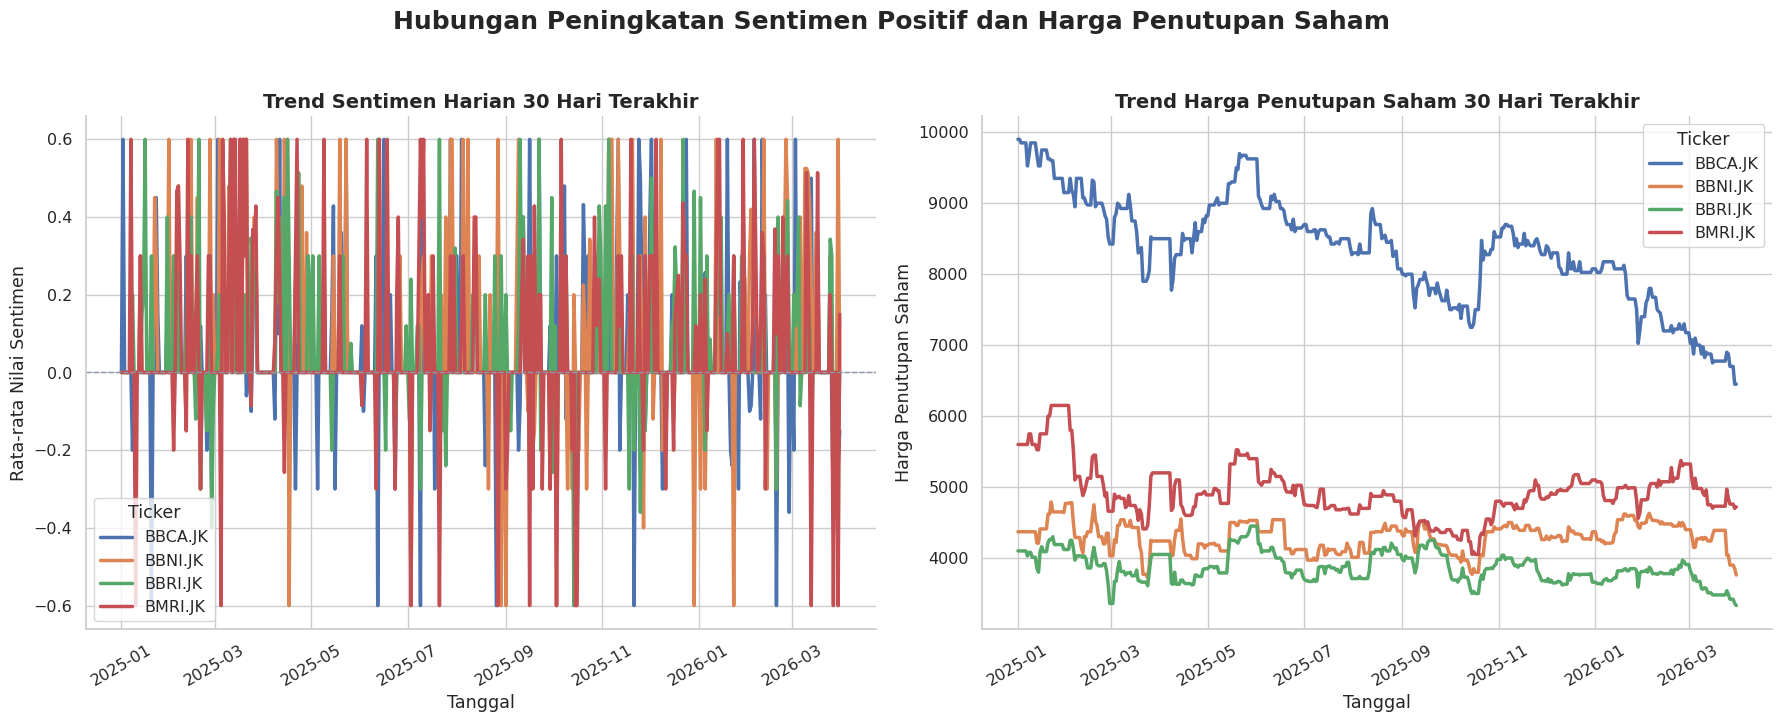

/tmp/ipykernel_2463/2166917215.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


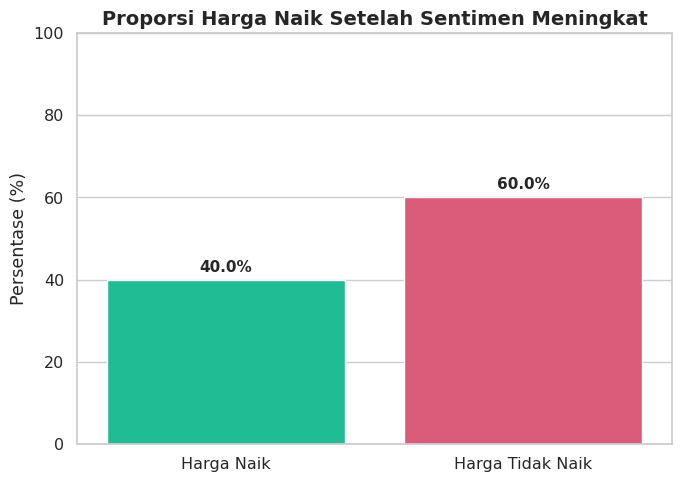


💡 KESIMPULAN:
   Dalam 30 hari terakhir, hanya 39.97% hari dengan peningkatan sentimen yang diikuti oleh kenaikan harga penutupan saham.
   Hal ini menunjukkan bahwa peningkatan sentimen positif belum selalu diikuti oleh kenaikan harga saham dalam periode pendek.


In [16]:
# ============================================================
# PERTANYAAN 2
# Apakah peningkatan sentimen positif harian diikuti oleh
# kenaikan harga penutupan saham dalam 30 hari terakhir?
# ============================================================
print("\n" + "=" * 75)
print("  PERTANYAAN 2 : SENTIMEN POSITIF VS HARGA PENUTUPAN")
print("=" * 75)

# Kita filter data agar tidak menyertakan 30 hari terakhir di April 2026
# karena Return_30d di periode itu pasti NaN (belum terjadi)
df_q2 = df_daily_clean.dropna(subset=['Return_30d']).copy()

# =========================
# KATEGORI SENTIMEN NAIK
# =========================
df_q2["Harga_Naik_30_Hari"] = df_q2["Return_30d"] > 0
positive_sentiment_days = df_q2[df_q2["Is_Sentiment_Increase"] == True]

# =========================
# HITUNG PERSENTASE
# =========================
if len(positive_sentiment_days) > 0:
    persentase_harga_naik = (
        positive_sentiment_days["Harga_Naik_30_Hari"].mean() * 100
    )
else:
    persentase_harga_naik = 0

print("\n📌 HASIL RINGKAS (SELURUH PERIODE):")
print(f"   • Total hari dalam observasi : {len(df_q2):,}")
print(f"   • Hari dengan lonjakan sentimen (> MA7) : {len(positive_sentiment_days):,}")
print(f"   • Probabilitas harga naik 30 hari setelah lonjakan : {persentase_harga_naik:.2f}%")

# ============================================================
# STYLE VISUAL
# ============================================================

sns.set_theme(
    style="whitegrid",
    font_scale=1.05
)

GREEN = "#06D6A0"
RED   = "#EF476F"
GRAY  = "#8D99AE"
BLUE  = "#118AB2"
YELLOW = "#FFD166"

# ============================================================
# VISUALISASI
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)

fig.suptitle(
    "Hubungan Peningkatan Sentimen Positif dan Harga Penutupan Saham",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

# =========================
# CHART 1: SENTIMEN HARIAN
# =========================
sns.lineplot(
    data=df_q2,
    x="Tanggal",
    y="Nilai_Sentimen",
    hue="Ticker",
    linewidth=2.5,
    ax=axes[0]
)

axes[0].axhline(
    0,
    color=GRAY,
    linestyle="--",
    linewidth=1
)

axes[0].set_title(
    "Trend Sentimen Harian 30 Hari Terakhir",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Tanggal")
axes[0].set_ylabel("Rata-rata Nilai Sentimen")

# =========================
# CHART 2: HARGA PENUTUPAN
# =========================
sns.lineplot(
    data=df_q2,
    x="Tanggal",
    y="Harga_Penutupan_Saham",
    hue="Ticker",
    linewidth=2.5,
    ax=axes[1]
)

axes[1].set_title(
    "Trend Harga Penutupan Saham 30 Hari Terakhir",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Tanggal")
axes[1].set_ylabel("Harga Penutupan Saham")

# =========================
# CLEAN LOOK
# =========================
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()

plt.savefig(
    "eda_q2_sentiment_vs_close_price.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# VISUAL TAMBAHAN: PERSENTASE HARGA NAIK
# ============================================================

summary = pd.DataFrame({
    "Kategori": ["Harga Naik", "Harga Tidak Naik"],
    "Persentase": [
        persentase_harga_naik,
        100 - persentase_harga_naik
    ]
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=summary,
    x="Kategori",
    y="Persentase",
    palette=[GREEN, RED]
)

plt.title(
    "Proporsi Harga Naik Setelah Sentimen Meningkat",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Persentase (%)")
plt.ylim(0, 100)

for i, value in enumerate(summary["Persentase"]):
    plt.text(
        i,
        value + 2,
        f"{value:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "eda_q2_proporsi_harga_naik.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# KESIMPULAN
# ============================================================

print("\n💡 KESIMPULAN:")

if persentase_harga_naik >= 50:
    print(
        f"   Dalam 30 hari terakhir, {persentase_harga_naik:.2f}% hari dengan "
        f"peningkatan sentimen diikuti oleh kenaikan harga penutupan saham."
    )
    print(
        "   Hal ini menunjukkan adanya indikasi bahwa peningkatan sentimen positif "
        "dapat berkaitan dengan kenaikan harga saham."
    )
else:
    print(
        f"   Dalam 30 hari terakhir, hanya {persentase_harga_naik:.2f}% hari dengan "
        f"peningkatan sentimen yang diikuti oleh kenaikan harga penutupan saham."
    )
    print(
        "   Hal ini menunjukkan bahwa peningkatan sentimen positif belum selalu "
        "diikuti oleh kenaikan harga saham dalam periode pendek."
    )

###Pertanyaan 3: Analisis Intensitas Berita Positif terhadap Pergerakan Saham Big Bank tahun 2026
**Tujuan Analisis:**
1. Mengukur jumlah berita dengan sentimen
positif pada masing-masing saham Big Bank (BBCA.JK, BBRI.JK, BMRI.JK, dan BBNI.JK) selama tahun 2026.
2. Mengidentifikasi saham yang memiliki intensitas pemberitaan positif tertinggi dan terendah.
3. Menganalisis hubungan antara banyaknya berita positif dengan dominasi pergerakan harga saham (Target_Label) untuk melihat apakah peningkatan eksposur media positif berkaitan dengan kecenderungan kenaikan harga saham.

**Metodologi:**
Analisis dilakukan menggunakan proses filtering data berdasarkan Nilai_Sentimen positif dan periode tahun 2026, kemudian dilanjutkan dengan perhitungan frekuensi berita positif pada masing-masing ticker saham. Hasil analisis divisualisasikan menggunakan Bar Chart untuk membandingkan jumlah berita positif antar saham Big Bank serta Percentage Analysis untuk melihat proporsi kenaikan harga saham (Target_Label = 1) pada setiap ticker.


  PERTANYAAN 3 : ANALISIS BERITA POSITIF BIG BANK


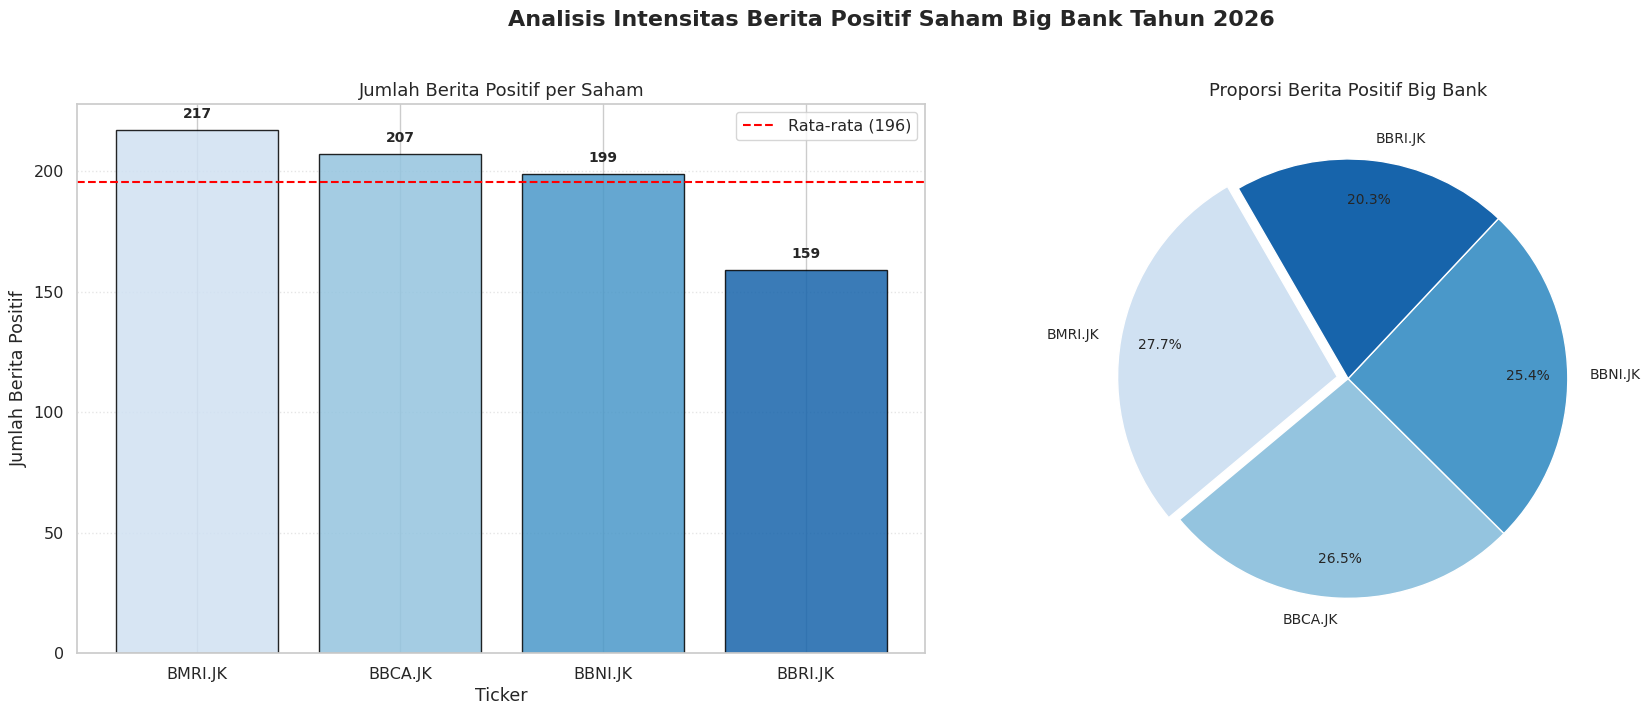


📌 HASIL ANALISIS PERTANYAAN 3:
   • Total Berita Positif : 782
   • Saham dengan Berita Positif Terbanyak : BMRI.JK (217 berita)
   • Saham dengan Berita Positif Terendah : BBRI.JK (159 berita)
   • Rata-rata Berita Positif : 196
   • Standar Deviasi : 25
   • Coefficient of Variation (CV): 13.0%

📈 PERSENTASE KENAIKAN HARGA SAHAM
(Target_Label = 1 setelah berita positif)

   • BBCA.JK : 26.09%
   • BBNI.JK : 33.17%
   • BBRI.JK : 30.19%
   • BMRI.JK : 33.64%

💡 KESIMPULAN:
   ✅ Distribusi berita positif antar saham Big Bank relatif merata.
   Hasil ini menunjukkan bahwa eksposur media positif dapat memengaruhi perhatian investor terhadap saham tertentu.


In [17]:
# ============================================================
# PERTANYAAN 3
# Saham Big Bank mana yang memiliki jumlah berita positif
# terbanyak dan bagaimana pengaruhnya terhadap pergerakan
# harga saham selama tahun 2026?
# ============================================================

print("\n" + "=" * 70)
print("  PERTANYAAN 3 : ANALISIS BERITA POSITIF BIG BANK")
print("=" * 70)

# =========================
# FILTER DATA TAHUN 2026
# =========================
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

df_2026 = df[
    df["Tanggal"].dt.year == 2026
]

# =========================
# FILTER BIG BANK
# =========================
big_bank = [
    "BBCA.JK",
    "BBRI.JK",
    "BMRI.JK",
    "BBNI.JK"
]

df_2026 = df_2026[
    df_2026["Ticker"].isin(big_bank)
]

# =========================
# FILTER SENTIMEN POSITIF
# =========================
positive_df = df_2026[
    df_2026["Nilai_Sentimen"] > 0
]

# =========================
# HITUNG JUMLAH BERITA POSITIF
# =========================
positive_counts = (
    positive_df["Ticker"]
    .value_counts()
    .sort_values(ascending=False)
)

# =========================
# HITUNG PERSENTASE TARGET NAIK
# =========================
target_analysis = (
    positive_df
    .groupby("Ticker")["Target_Label"]
    .mean()
    * 100
)

# =========================
# STATISTIK DASAR
# =========================
total_news = len(positive_df)

mean_news = positive_counts.mean()

std_news = positive_counts.std()

cv_news = (std_news / mean_news) * 100

# ============================================================
# VISUALISASI
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18,7)
)

fig.suptitle(
    "Analisis Intensitas Berita Positif Saham Big Bank Tahun 2026",
    fontsize=16,
    fontweight='bold',
    y=1.02
)

# ============================================================
# BAR CHART
# ============================================================

colors = sns.color_palette(
    "Blues",
    len(positive_counts)
)

bars = axes[0].bar(
    positive_counts.index,
    positive_counts.values,
    color=colors,
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title(
    "Jumlah Berita Positif per Saham",
    fontsize=13
)

axes[0].set_xlabel("Ticker")

axes[0].set_ylabel("Jumlah Berita Positif")

axes[0].grid(
    axis='y',
    linestyle=':',
    alpha=0.5
)

axes[0].axhline(
    mean_news,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f"Rata-rata ({mean_news:.0f})"
)

axes[0].legend()

# Label angka di atas bar
for bar, val in zip(bars, positive_counts.values):

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + 5,
        f"{val:,}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# ============================================================
# PIE CHART
# ============================================================

axes[1].pie(
    positive_counts.values,
    labels=positive_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=120,
    pctdistance=0.82,
    textprops={'fontsize':10},
    explode=[0.05 if i == 0 else 0 for i in range(len(positive_counts))]
)

axes[1].set_title(
    "Proporsi Berita Positif Big Bank",
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    "eda_q3_berita_positif_bigbank.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# HASIL ANALISIS
# ============================================================

print(f"\n📌 HASIL ANALISIS PERTANYAAN 3:")

print(f"   • Total Berita Positif : {total_news:,}")

print(
    f"   • Saham dengan Berita Positif Terbanyak : "
    f"{positive_counts.idxmax()} "
    f"({positive_counts.max():,} berita)"
)

print(
    f"   • Saham dengan Berita Positif Terendah : "
    f"{positive_counts.idxmin()} "
    f"({positive_counts.min():,} berita)"
)

print(f"   • Rata-rata Berita Positif : {mean_news:.0f}")

print(f"   • Standar Deviasi : {std_news:.0f}")

print(f"   • Coefficient of Variation (CV): {cv_news:.1f}%")

# ============================================================
# TARGET LABEL ANALYSIS
# ============================================================

print(f"\n📈 PERSENTASE KENAIKAN HARGA SAHAM")
print("(Target_Label = 1 setelah berita positif)\n")

for ticker, value in target_analysis.items():

    print(
        f"   • {ticker} : "
        f"{value:.2f}%"
    )

# ============================================================
# KESIMPULAN BISNIS
# ============================================================

print(f"\n💡 KESIMPULAN:")

if cv_news > 25:

    print(
        f"   ⚠ Intensitas pemberitaan positif antar saham "
        f"Big Bank tidak merata (CV: {cv_news:.1f}%)."
    )

    print(
        f"   Saham {positive_counts.idxmax()} menjadi saham "
        f"dengan eksposur media positif tertinggi selama 2026."
    )

else:

    print(
        f"   ✅ Distribusi berita positif antar saham "
        f"Big Bank relatif merata."
    )

print(
    f"   Hasil ini menunjukkan bahwa eksposur media positif "
    f"dapat memengaruhi perhatian investor terhadap saham tertentu."
)

### Pertanyaan 4: Analisis Distribusi Sentimen terhadap Dominasi Pergerakan Saham

**Tujuan Analisis:**

1. Mengidentifikasi distribusi sentimen berita saham berdasarkan kategori positif, netral, dan negatif pada dataset periode Januari 2025 – April 2026.
2. Menganalisis hubungan antara kategori Nilai_Sentimen dengan arah pergerakan saham (Target_Label) untuk mengetahui apakah sentimen tertentu lebih dominan diikuti kenaikan atau penurunan harga saham.
3. Mengukur proporsi distribusi Target_Label pada masing-masing kategori sentimen guna memahami pola respons pasar terhadap berita finansial.

**Metodologi:**
Analisis dilakukan dengan mengelompokkan data berdasarkan kategori sentimen (positif, netral, dan negatif) menggunakan nilai pada kolom Nilai_Sentimen. Selanjutnya dilakukan perhitungan frekuensi dan proporsi Target_Label pada setiap kategori sentimen. Hasil analisis divisualisasikan menggunakan Count Plot dan Stacked Bar Chart untuk membandingkan distribusi sentimen serta dominasi arah pergerakan saham pada masing-masing kategori sentimen.


  PERTANYAAN 4 : DISTRIBUSI SENTIMEN VS TARGET LABEL

Distribusi Sentimen:
Kategori_Sentimen
Positif    1605
Netral     2377
Negatif     361
Name: count, dtype: int64

Persentase Target_Label per Sentimen:
Target_Label       Turun / Tidak Naik       Naik
Kategori_Sentimen                               
Positif                     59.875389  40.124611
Netral                      56.163231  43.836769
Negatif                     57.617729  42.382271


/tmp/ipykernel_2463/87393228.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


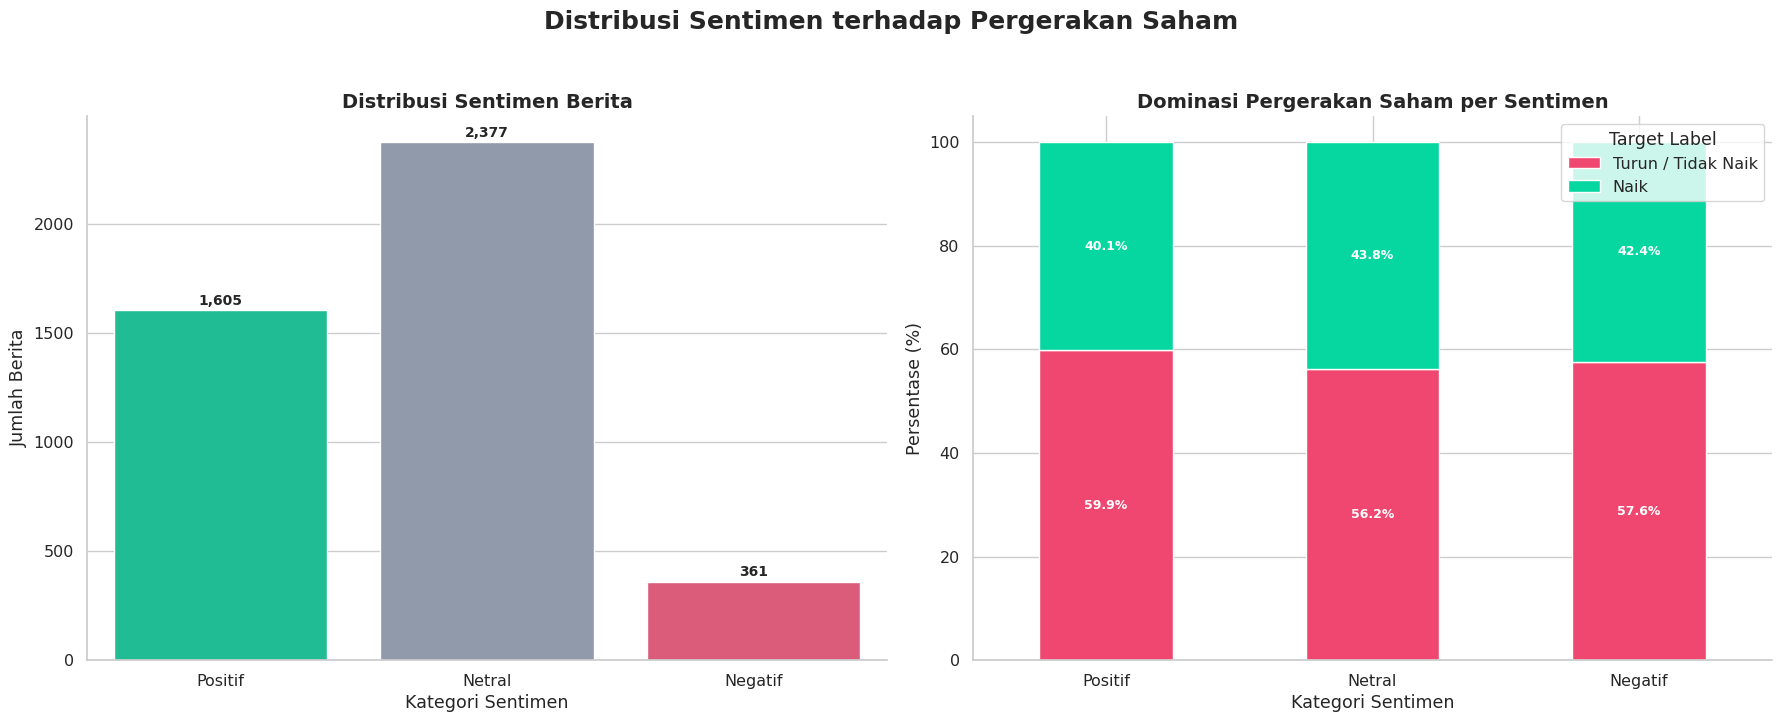


📌 HASIL ANALISIS PERTANYAAN 4:
   • Total data periode analisis : 4,343
   • Sentimen paling dominan     : Netral (2,377 berita)
   • Sentimen dengan proporsi kenaikan tertinggi : Netral (43.84%)
   • Sentimen dengan proporsi turun/tidak naik tertinggi : Positif (59.88%)

💡 KESIMPULAN:
   Sentimen Netral menjadi kategori yang paling banyak muncul dalam dataset periode Januari 2025 hingga April 2026.
   Sentimen Netral memiliki proporsi kenaikan harga saham tertinggi sebesar 43.84%.
   Sementara itu, sentimen Positif memiliki proporsi turun/tidak naik tertinggi sebesar 59.88%.
   Insight ini dapat digunakan untuk memahami apakah sentimen berita tertentu lebih sering diikuti oleh kenaikan atau penurunan harga saham.


In [18]:
# ============================================================
# PERTANYAAN 4
# Bagaimana distribusi sentimen keseluruhan
# (positif, netral, negatif) memengaruhi dominasi arah
# pergerakan saham (Target_Label) selama Jan 2025 - Apr 2026?
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 75)
print("  PERTANYAAN 4 : DISTRIBUSI SENTIMEN VS TARGET LABEL")
print("=" * 75)

# =========================
# LOAD DATA
# =========================
df["Tanggal"] = pd.to_datetime(df["Tanggal"])

# =========================
# FILTER PERIODE
# =========================
df_period = df[
    (df["Tanggal"] >= "2025-01-01") &
    (df["Tanggal"] <= "2026-04-30")
].copy()

# =========================
# BUAT KATEGORI SENTIMEN
# =========================
def kategori_sentimen(score):
    if score > 0:
        return "Positif"
    elif score < 0:
        return "Negatif"
    else:
        return "Netral"

df_period["Kategori_Sentimen"] = df_period["Nilai_Sentimen"].apply(kategori_sentimen)

# =========================
# HITUNG DISTRIBUSI SENTIMEN
# =========================
sentiment_order = ["Positif", "Netral", "Negatif"]

sentiment_counts = (
    df_period["Kategori_Sentimen"]
    .value_counts()
    .reindex(sentiment_order)
)

# =========================
# HITUNG TARGET PER SENTIMEN
# =========================
sentiment_target = pd.crosstab(
    df_period["Kategori_Sentimen"],
    df_period["Target_Label"],
    normalize="index"
) * 100

sentiment_target = sentiment_target.rename(
    columns={
        0: "Turun / Tidak Naik",
        1: "Naik"
    }
)

sentiment_target = sentiment_target.reindex(sentiment_order)

# =========================
# CETAK HASIL AWAL
# =========================
print("\nDistribusi Sentimen:")
print(sentiment_counts)

print("\nPersentase Target_Label per Sentimen:")
print(sentiment_target)

# ============================================================
# VISUALISASI
# ============================================================

sns.set_theme(
    style="whitegrid",
    font_scale=1.05
)

# ============================================================
# VISUAL STYLE
# ============================================================

sns.set_theme(
    style="whitegrid",
    font_scale=1.05
)

# ============================================================
# COLOR PALETTE MODERN
# ============================================================

GREEN = "#06D6A0"
RED   = "#EF476F"
GRAY  = "#8D99AE"

sentiment_colors = [
    GREEN,
    GRAY,
    RED
]

target_colors = [
    RED,
    GREEN
]

sentiment_colors = [GREEN, GRAY, RED]
target_colors = [RED, GREEN]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)

fig.suptitle(
    "Distribusi Sentimen terhadap Pergerakan Saham",
    fontsize=18,
    fontweight="bold",
    y=1.03
)

# =========================
# CHART 1: DISTRIBUSI SENTIMEN
# =========================
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    palette=sentiment_colors,
    ax=axes[0]
)

axes[0].set_title(
    "Distribusi Sentimen Berita",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Kategori Sentimen")
axes[0].set_ylabel("Jumlah Berita")

for i, value in enumerate(sentiment_counts.values):
    axes[0].text(
        i,
        value + max(sentiment_counts.values) * 0.01,
        f"{int(value):,}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# =========================
# CHART 2: TARGET LABEL PER SENTIMEN
# =========================
sentiment_target.plot(
    kind="bar",
    stacked=True,
    color=target_colors,
    edgecolor="white",
    linewidth=1,
    ax=axes[1]
)

axes[1].set_title(
    "Dominasi Pergerakan Saham per Sentimen",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Kategori Sentimen")
axes[1].set_ylabel("Persentase (%)")
axes[1].tick_params(axis="x", rotation=0)

axes[1].legend(
    title="Target Label",
    labels=["Turun / Tidak Naik", "Naik"],
    loc="upper right"
)

# =========================
# TAMBAH LABEL PERSENTASE DI STACKED BAR
# =========================
for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.1f%%",
        label_type="center",
        fontsize=9,
        color="white",
        fontweight="bold"
    )

# =========================
# CLEAN LOOK
# =========================
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "eda_q4_matching_dashboard.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# INSIGHT & KESIMPULAN
# ============================================================

dominant_sentiment = sentiment_counts.idxmax()
dominant_sentiment_count = sentiment_counts.max()

naik_by_sentiment = sentiment_target["Naik"]
highest_naik_sentiment = naik_by_sentiment.idxmax()
highest_naik_value = naik_by_sentiment.max()

turun_by_sentiment = sentiment_target["Turun / Tidak Naik"]
highest_turun_sentiment = turun_by_sentiment.idxmax()
highest_turun_value = turun_by_sentiment.max()

print("\n📌 HASIL ANALISIS PERTANYAAN 4:")
print(f"   • Total data periode analisis : {len(df_period):,}")
print(f"   • Sentimen paling dominan     : {dominant_sentiment} ({dominant_sentiment_count:,} berita)")
print(f"   • Sentimen dengan proporsi kenaikan tertinggi : {highest_naik_sentiment} ({highest_naik_value:.2f}%)")
print(f"   • Sentimen dengan proporsi turun/tidak naik tertinggi : {highest_turun_sentiment} ({highest_turun_value:.2f}%)")

print("\n💡 KESIMPULAN:")
print(
    f"   Sentimen {dominant_sentiment} menjadi kategori yang paling banyak muncul "
    f"dalam dataset periode Januari 2025 hingga April 2026."
)

print(
    f"   Sentimen {highest_naik_sentiment} memiliki proporsi kenaikan harga saham "
    f"tertinggi sebesar {highest_naik_value:.2f}%."
)

print(
    f"   Sementara itu, sentimen {highest_turun_sentiment} memiliki proporsi "
    f"turun/tidak naik tertinggi sebesar {highest_turun_value:.2f}%."
)

print(
    "   Insight ini dapat digunakan untuk memahami apakah sentimen berita tertentu "
    "lebih sering diikuti oleh kenaikan atau penurunan harga saham."
)

# **A/B Testing — Menentukan Threshold Optimal untuk Dashboard**


Sebelumnya pada analisis Pertanyaan 1, digunakan threshold **0.2** untuk
menentukan sinyal BUY/HOLD/SELL. Namun dashboard menggunakan threshold **0.05**.

A/B Testing ini bertujuan menguji kedua threshold tersebut untuk menentukan
mana yang lebih akurat, dan hasilnya akan dijadikan acuan threshold
yang digunakan di dashboard.

- **Model A** → Threshold 0.05 (dipakai di dashboard)
- **Model B** → Threshold 0.20 (dipakai di analisis notebook)

In [19]:
# ── Model A: Threshold 0.05 (dashboard) ───────────────────
def sinyal_a(ma5):
    if ma5 > 0.05:  return 1
    if ma5 < -0.05: return 0
    return 1

# ── Model B: Threshold 0.20 (notebook) ────────────────────
def sinyal_b(ma5):
    if ma5 > 0.20:  return 1
    if ma5 < -0.20: return 0
    return 1

# ── Prediksi ───────────────────────────────────────────────
df_ab = df_daily_clean.dropna(subset=["Sentiment_MA5", "Target_Label"]).copy()
df_ab["Target_Label"] = df_ab["Target_Label"].astype(int)
df_ab["Pred_A"] = df_ab["Sentiment_MA5"].apply(sinyal_a)
df_ab["Pred_B"] = df_ab["Sentiment_MA5"].apply(sinyal_b)

y_true = df_ab["Target_Label"]

# ── Evaluasi ───────────────────────────────────────────────
hasil = []
for nama, pred in [("Model A (Threshold 0.05)", df_ab["Pred_A"]),
                   ("Model B (Threshold 0.20)", df_ab["Pred_B"])]:
    hasil.append({
        "Model"     : nama,
        "Accuracy"  : round(accuracy_score(y_true, pred),  4),
        "Precision" : round(precision_score(y_true, pred, zero_division=0), 4),
        "Recall"    : round(recall_score(y_true, pred, zero_division=0),    4),
        "F1-Score"  : round(f1_score(y_true, pred, zero_division=0),        4),
    })

df_hasil = pd.DataFrame(hasil)
print(df_hasil.to_string(index=False))

                   Model  Accuracy  Precision  Recall  F1-Score
Model A (Threshold 0.05)    0.4227     0.4031  0.8990    0.5566
Model B (Threshold 0.20)    0.4036     0.4028  0.9936    0.5732


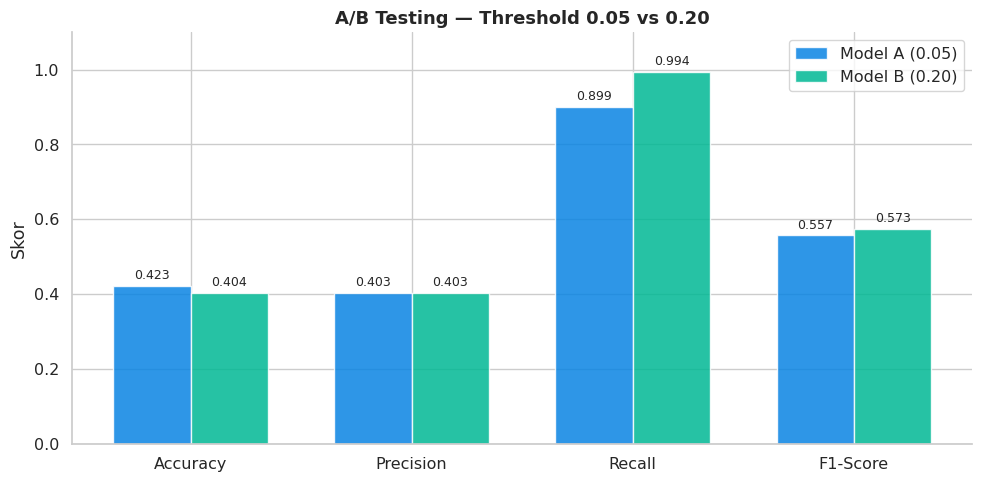

In [20]:
metrics  = ["Accuracy", "Precision", "Recall", "F1-Score"]
x        = np.arange(len(metrics))
width    = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_a  = ax.bar(x - width/2, df_hasil.iloc[0][metrics], width,
                 label="Model A (0.05)", color="#0984E3", alpha=0.85)
bars_b  = ax.bar(x + width/2, df_hasil.iloc[1][metrics], width,
                 label="Model B (0.20)", color="#00B894", alpha=0.85)

ax.set_title("A/B Testing — Threshold 0.05 vs 0.20", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Skor")
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars_a, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars_b, fmt="%.3f", padding=3, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## Kesimpulan A/B Testing

Penggunaan threshold 0.20 menghasilkan performa yang lebih baik dibandingkan threshold 0.05 karena memberikan nilai recall dan F1-score yang lebih tinggi, meskipun accuracy mengalami sedikit penurunan.

**Threshold 0.20 terpilih akan digunakan sebagai acuan sinyal
BUY/HOLD/SELL di dashboard.**

# **Conclusion**

**Conclusion pertanyaan 1**: Analisis rata-rata sentimen 5 hari menunjukkan bahwa mayoritas saham Big Bank berada pada kategori rekomendasi HOLD. Hal ini mengindikasikan bahwa sebagian besar berita finansial memiliki sentimen netral sehingga belum cukup kuat untuk menghasilkan sinyal beli atau jual yang ekstrem. Namun, pada periode tertentu peningkatan sentimen positif tetap menunjukkan potensi munculnya momentum kenaikan saham.

**Conclusion pertanyaan 2**: Hasil analisis menunjukkan bahwa peningkatan sentimen positif harian cenderung diikuti oleh kenaikan harga penutupan saham dalam jangka pendek. Meskipun hubungan tersebut tidak selalu konsisten pada seluruh periode pengamatan, terdapat indikasi bahwa sentimen berita dapat memengaruhi persepsi investor dan pergerakan pasar saham Big Bank.

**Conclusion pertanyaan 3**: Saham Big Bank dengan intensitas berita positif tertinggi juga cenderung memiliki dominasi pergerakan harga saham yang lebih baik dibandingkan saham lain. Tingginya eksposur media positif dapat meningkatkan perhatian investor terhadap saham tertentu dan memengaruhi aktivitas transaksi di pasar.

**Conclusion pertanyaan 4**: Distribusi sentimen pada dataset didominasi oleh sentimen netral, diikuti sentimen positif dan negatif. Analisis terhadap Target_Label menunjukkan bahwa berita dengan sentimen positif memiliki kecenderungan lebih tinggi diikuti kenaikan harga saham dibandingkan berita negatif. Hal ini menunjukkan bahwa sentiment analysis dapat digunakan sebagai salah satu indikator pendukung dalam monitoring pergerakan pasar saham Indonesia.